In [1]:
# Import necessary libraries for data manipulation, numerical computations, and plotting
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pygmt

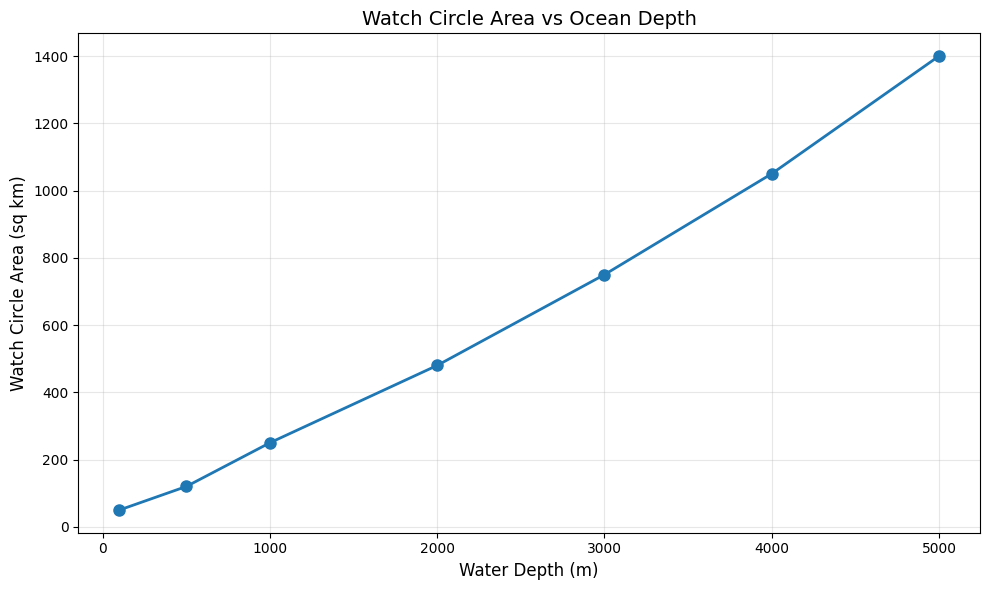

In [2]:
# Section 1: Sample Data and Basic Plot
# This cell provides sample data for watch circle area at different depths and creates a basic line plot
# to visualize the relationship between ocean depth and watch circle area.
depth = np.array([100, 500, 1000, 2000, 3000, 4000, 5000])
watch_circle_area = np.array([50, 120, 250, 480, 750, 1050, 1400])

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(depth, watch_circle_area, marker='o', linewidth=2, markersize=8)
plt.xlabel('Water Depth (m)', fontsize=12)
plt.ylabel('Watch Circle Area (sq km)', fontsize=12)
plt.title('Watch Circle Area vs Ocean Depth', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

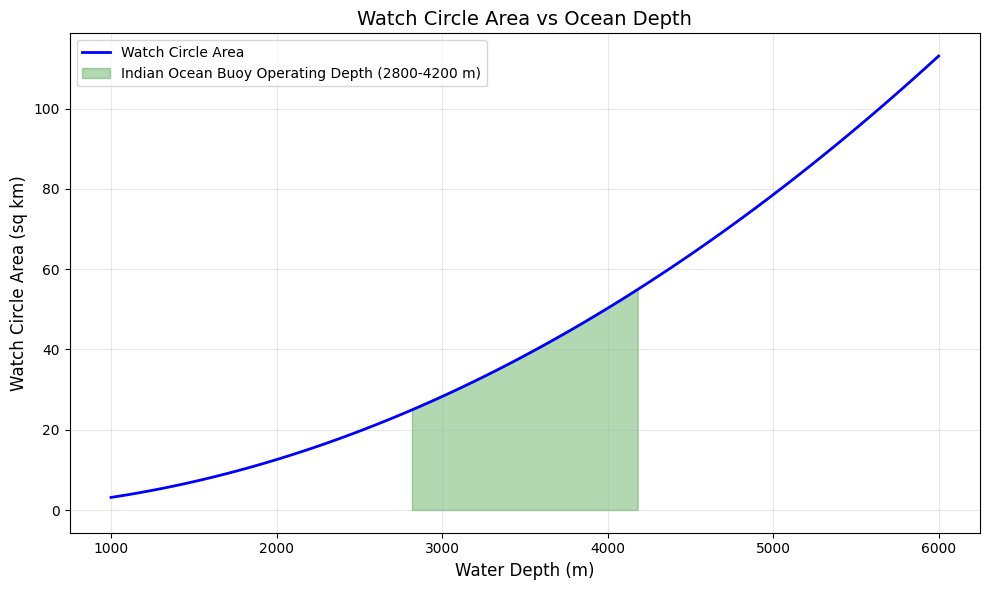

In [3]:
# Section 2: Continuous Depth Data and Operating Depth Highlight
# This cell generates continuous depth values and calculates watch circle area using the formula π * depth².
# It then plots the area vs depth and highlights the Indian Ocean buoy operating depth range (2800-4200 m).
depth = np.linspace(1000, 6000, 100)

# Calculate watch circle area: π * depth²
watch_circle_area = np.pi * depth**2 * 1e-6  # Convert to square kilometers

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(depth, watch_circle_area, linewidth=2, color='blue', label='Watch Circle Area')

# Highlight the Indian Ocean buoy deployment operating depth (2800-4200 m)
mask = (depth >= 2800) & (depth <= 4200)
plt.fill_between(depth[mask], watch_circle_area[mask], alpha=0.3, color='green', label='Indian Ocean Buoy Operating Depth (2800-4200 m)')

plt.xlabel('Water Depth (m)', fontsize=12)
plt.ylabel('Watch Circle Area (sq km)', fontsize=12)
plt.title('Watch Circle Area vs Ocean Depth', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

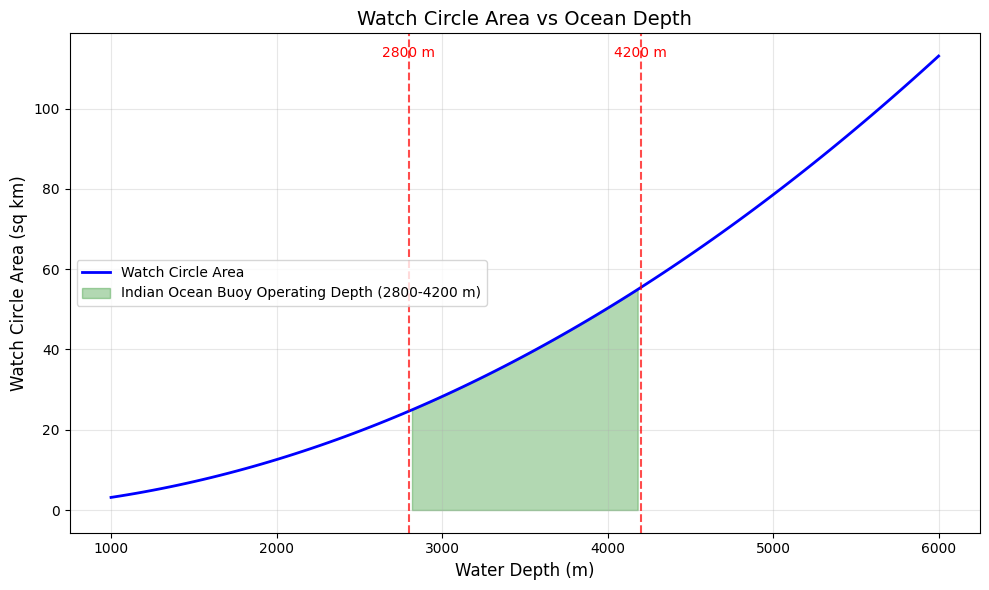

In [4]:
# Section 3: Plot with Boundary Depth Markers
# This cell creates the same plot as above but adds vertical lines and labels for the boundary depths (2800m and 4200m)
# to clearly mark the operating depth range.
plt.figure(figsize=(10, 6))
plt.plot(depth, watch_circle_area, linewidth=2, color='blue', label='Watch Circle Area')

# Highlight the Indian Ocean buoy deployment operating depth (2800-4200 m)
plt.fill_between(depth[mask], watch_circle_area[mask], alpha=0.3, color='green', label='Indian Ocean Buoy Operating Depth (2800-4200 m)')

# Add boundary ocean depth labels on x-axis
boundary_depths = [2800, 4200]
for bd in boundary_depths:
    plt.axvline(x=bd, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
    plt.text(bd, plt.ylim()[1] * 0.95, f'{bd} m', rotation=0, ha='center', fontsize=10, color='red')

plt.xlabel('Water Depth (m)', fontsize=12)
plt.ylabel('Watch Circle Area (sq km)', fontsize=12)
plt.title('Watch Circle Area vs Ocean Depth', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

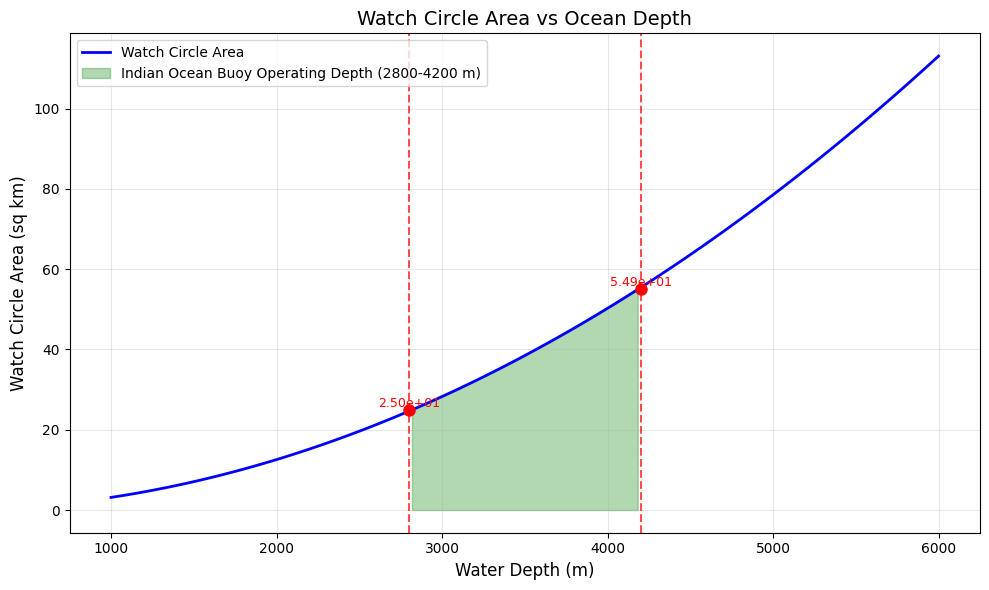

In [5]:
# Section 4: Plot with Intersection Points and Area Labels
# This cell enhances the plot by adding red markers at the boundary depths and labeling the corresponding watch circle areas
# to show the exact values at the operating depth limits.
plt.figure(figsize=(10, 6))
plt.plot(depth, watch_circle_area, linewidth=2, color='blue', label='Watch Circle Area')

# Highlight the Indian Ocean buoy deployment operating depth (2800-4200 m)
plt.fill_between(depth[mask], watch_circle_area[mask], alpha=0.3, color='green', label='Indian Ocean Buoy Operating Depth (2800-4200 m)')

# Add boundary ocean depth labels on x-axis and corresponding watch circle area labels
boundary_depths = [2800, 4200]
for bd in boundary_depths:
    plt.axvline(x=bd, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
    idx = np.argmin(np.abs(depth - bd))
    ba = watch_circle_area[idx]
    plt.plot(bd, ba, 'ro', markersize=8)  # Mark the intersection point
    plt.text(bd, ba, f'{ba:.2e}', rotation=0, ha='center', va='bottom', fontsize=9, color='red')

plt.xlabel('Water Depth (m)', fontsize=12)
plt.ylabel('Watch Circle Area (sq km)', fontsize=12)
plt.title('Watch Circle Area vs Ocean Depth', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

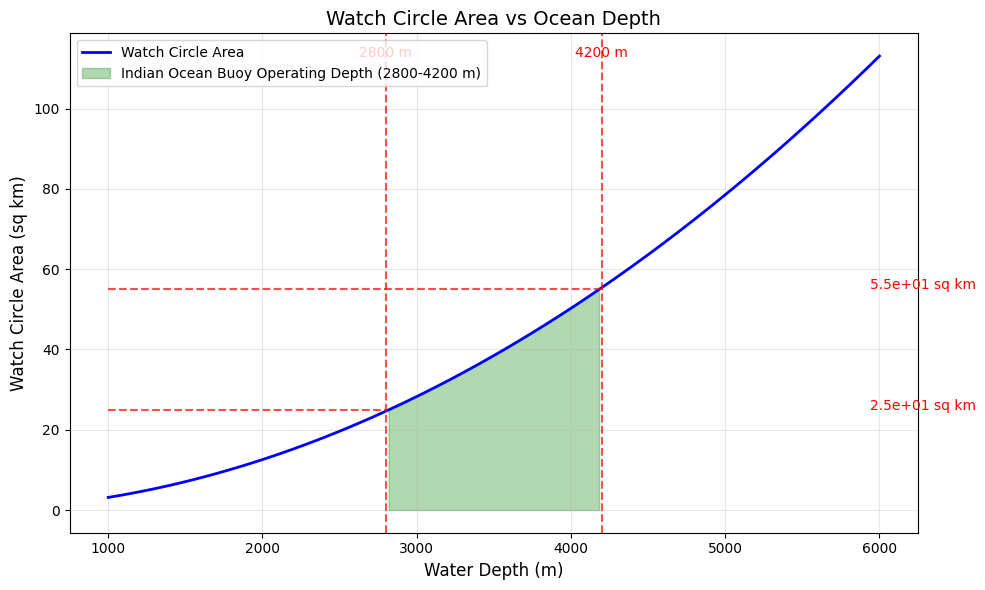

In [6]:
# Section 5: Plot with Horizontal Area Reference Lines
# This cell adds horizontal dashed lines from the left edge to the boundary depths, with area labels on the right y-axis
# to provide visual reference for the watch circle areas at the operating depth boundaries.
plt.figure(figsize=(10, 6))
plt.plot(depth, watch_circle_area, linewidth=2, color='blue', label='Watch Circle Area')

# Highlight the Indian Ocean buoy deployment operating depth (2800-4200 m)
plt.fill_between(depth[mask], watch_circle_area[mask], alpha=0.3, color='green', label='Indian Ocean Buoy Operating Depth (2800-4200 m)')

# Add boundary ocean depth labels on x-axis
boundary_depths = [2800, 4200]
for bd in boundary_depths:
    plt.axvline(x=bd, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
    plt.text(bd, plt.ylim()[1] * 0.95, f'{bd} m', rotation=0, ha='center', fontsize=10, color='red')

# Add boundary watch circle area labels on y-axis
for bd in boundary_depths:
    idx = np.argmin(np.abs(depth - bd))
    ba = watch_circle_area[idx]
    plt.plot([depth[0], bd], [ba, ba], color='red', linestyle='--', linewidth=1.5, alpha=0.7)
    plt.text(plt.xlim()[1] * 0.95, ba, f'{ba:.1e} sq km', rotation=0, ha='left', fontsize=10, color='red')

plt.xlabel('Water Depth (m)', fontsize=12)
plt.ylabel('Watch Circle Area (sq km)', fontsize=12)
plt.title('Watch Circle Area vs Ocean Depth', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
# Section 6: Acoustic Projection Cone Calculation
# This cell calculates the acoustic projection area for a 20-degree full cone (10-degree half-angle) using the formula for cone base area.
# It then prints the calculated areas at the boundary depths (2800m and 4200m).
half_theta_deg = 10
radius = depth * np.tan(np.radians(half_theta_deg))
acoustic_projection_area = np.pi * radius**2 * 1e-6  # Convert to square kilometers

# Print the areas for the boundary depths
for bd in boundary_depths:
    idx = np.argmin(np.abs(depth - bd))
    area = acoustic_projection_area[idx]
    print(f"At depth {bd} m, acoustic projection area: {area:.2e} sq km")

At depth 2800 m, acoustic projection area: 7.76e-01 sq km
At depth 4200 m, acoustic projection area: 1.71e+00 sq km


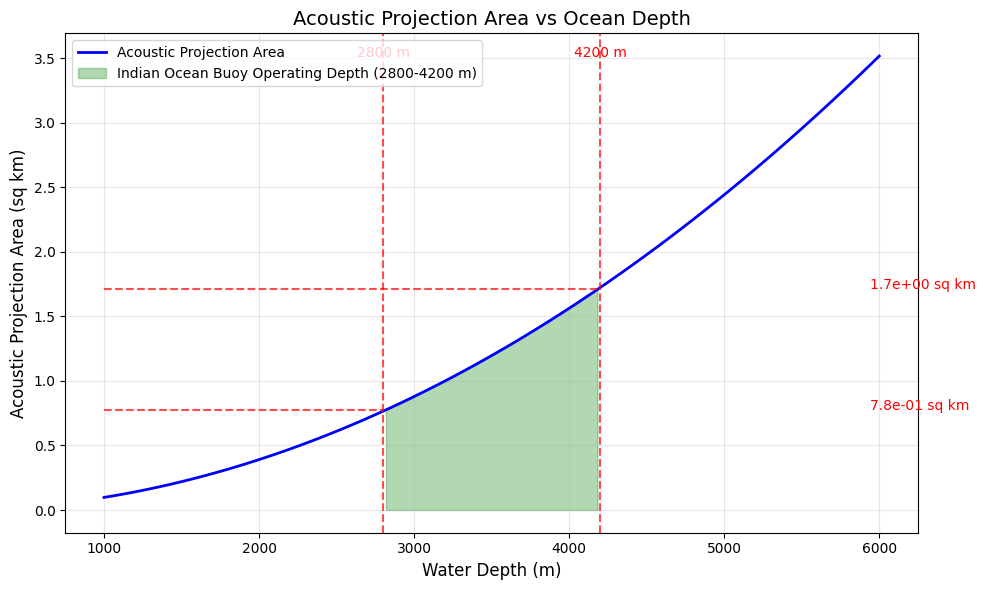

In [8]:
# Section 7: Acoustic Projection Area Plot
# This cell plots the acoustic projection area vs depth for the 20° cone, with the same highlighting and labeling
# as the watch circle plots, to compare the projection coverage area.
plt.figure(figsize=(10, 6))
plt.plot(depth, acoustic_projection_area, linewidth=2, color='blue', label='Acoustic Projection Area')

# Highlight the Indian Ocean buoy deployment operating depth (2800-4200 m)
plt.fill_between(depth[mask], acoustic_projection_area[mask], alpha=0.3, color='green', label='Indian Ocean Buoy Operating Depth (2800-4200 m)')

# Add boundary ocean depth labels on x-axis
for bd in boundary_depths:
    plt.axvline(x=bd, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
    plt.text(bd, plt.ylim()[1] * 0.95, f'{bd} m', rotation=0, ha='center', fontsize=10, color='red')

# Add boundary acoustic projection area labels on y-axis
for bd in boundary_depths:
    idx = np.argmin(np.abs(depth - bd))
    ba = acoustic_projection_area[idx]
    plt.plot([depth[0], bd], [ba, ba], color='red', linestyle='--', linewidth=1.5, alpha=0.7)
    plt.text(plt.xlim()[1] * 0.95, ba, f'{ba:.1e} sq km', rotation=0, ha='left', fontsize=10, color='red')

plt.xlabel('Water Depth (m)', fontsize=12)
plt.ylabel('Acoustic Projection Area (sq km)', fontsize=12)
plt.title('Acoustic Projection Area vs Ocean Depth', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

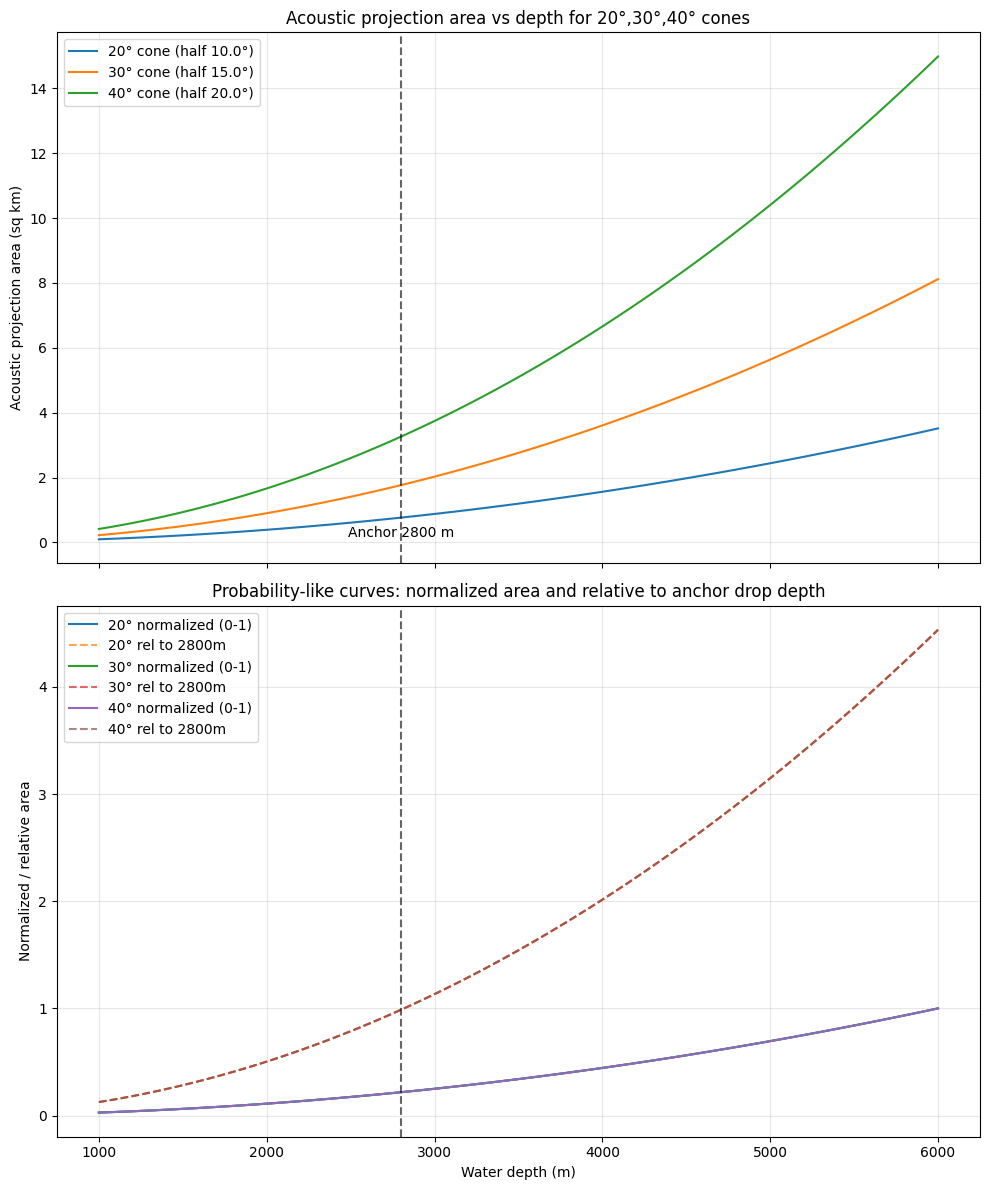

In [9]:
# Section 8: Multi-Cone Analysis (20°, 30°, 40°)
# This cell computes acoustic projection areas for multiple cone angles (20°, 30°, 40°) and creates comparative plots.
# It shows absolute areas vs depth and normalized/relative curves anchored at 2800m depth.
cone_angles = [20, 30, 40]
half_angles = [ang / 2 for ang in cone_angles]

anchor_drop_depth = 2800
anchor_idx = np.argmin(np.abs(depth - anchor_drop_depth))

area_curves = {}
relative_curves = {}
probability_curves = {}

for ha, angle in zip(half_angles, cone_angles):
    rad = np.radians(ha)
    r = depth * np.tan(rad)
    area = np.pi * r**2 * 1e-6  # sq km
    area_anchor = area[anchor_idx]
    area_curves[angle] = area
    relative_curves[angle] = area / area_anchor
    probability_curves[angle] = area / area.max()

fig, axes = plt.subplots(2, 1, figsize=(10, 12), sharex=True)

# absolute area
for angle in cone_angles:
    axes[0].plot(depth, area_curves[angle], label=f'{angle}° cone (half {angle/2}°)')
axes[0].axvline(anchor_drop_depth, color='black', linestyle='--', alpha=0.6)
axes[0].text(anchor_drop_depth, axes[0].get_ylim()[0] + 0.05*(axes[0].get_ylim()[1]-axes[0].get_ylim()[0]),
             f'Anchor {anchor_drop_depth} m', ha='center', color='black')
axes[0].set_ylabel('Acoustic projection area (sq km)')
axes[0].set_title('Acoustic projection area vs depth for 20°,30°,40° cones')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# relative / probability curves
for angle in cone_angles:
    axes[1].plot(depth, probability_curves[angle], label=f'{angle}° normalized (0-1)')
    axes[1].plot(depth, relative_curves[angle], linestyle='--', alpha=0.7, label=f'{angle}° rel to {anchor_drop_depth}m')
axes[1].axvline(anchor_drop_depth, color='black', linestyle='--', alpha=0.6)
axes[1].set_xlabel('Water depth (m)')
axes[1].set_ylabel('Normalized / relative area')
axes[1].set_title('Probability-like curves: normalized area and relative to anchor drop depth')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

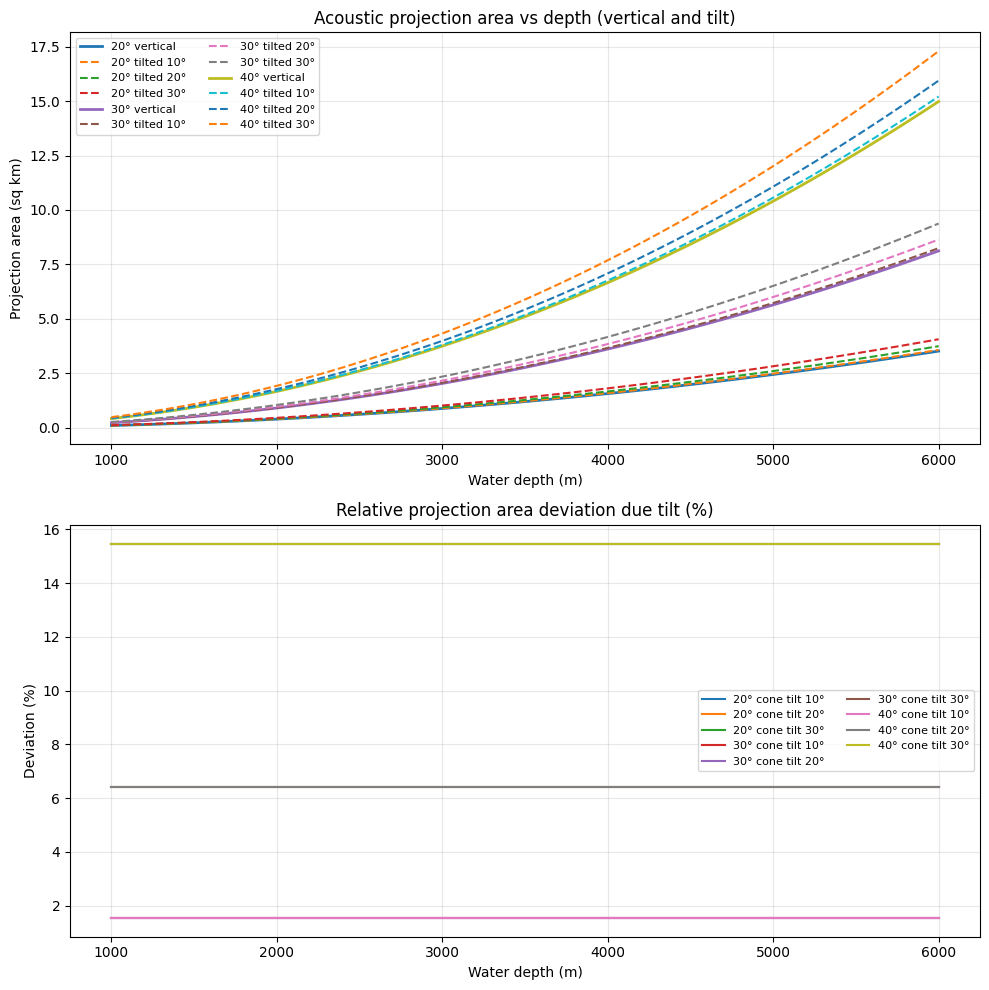

In [10]:
# Section 9: Tilt Impact Analysis for Multiple Cones
# This cell explores how tilting the acoustic cones affects the projection area.
# It shows absolute areas with tilt and the relative percentage deviation from vertical orientation.
full_cone_angles = [20, 30, 40]   # degrees
tilt_angles = [0, 10, 20, 30]     # tilt from vertical in degrees

plt.figure(figsize=(10, 10))

# 1) Absolute projection area vs depth for vertical + tilted cones
ax1 = plt.subplot(2, 1, 1)
for ang in full_cone_angles:
    half = ang / 2.0
    area_vertical = np.pi * (depth * np.tan(np.radians(half)))**2 * 1e-6
    ax1.plot(depth, area_vertical, linewidth=2, label=f'{ang}° vertical')
    for tilt in tilt_angles[1:]:
        area_tilt = area_vertical / np.cos(np.radians(tilt))
        ax1.plot(depth, area_tilt, linestyle='--', linewidth=1.5,
                 label=f'{ang}° tilted {tilt}°')

ax1.set_title('Acoustic projection area vs depth (vertical and tilt)')
ax1.set_xlabel('Water depth (m)')
ax1.set_ylabel('Projection area (sq km)')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=8, ncol=2)

# 2) Deviation due tilt (relative change % from vertical)
ax2 = plt.subplot(2, 1, 2, sharex=ax1)
for ang in full_cone_angles:
    half = ang / 2.0
    area_vertical = np.pi * (depth * np.tan(np.radians(half)))**2 * 1e-6
    for tilt in tilt_angles[1:]:
        area_tilt = area_vertical / np.cos(np.radians(tilt))
        rel_change = 100.0 * (area_tilt - area_vertical) / area_vertical
        ax2.plot(depth, rel_change, label=f'{ang}° cone tilt {tilt}°')

ax2.set_title('Relative projection area deviation due tilt (%)')
ax2.set_xlabel('Water depth (m)')
ax2.set_ylabel('Deviation (%)')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.show()

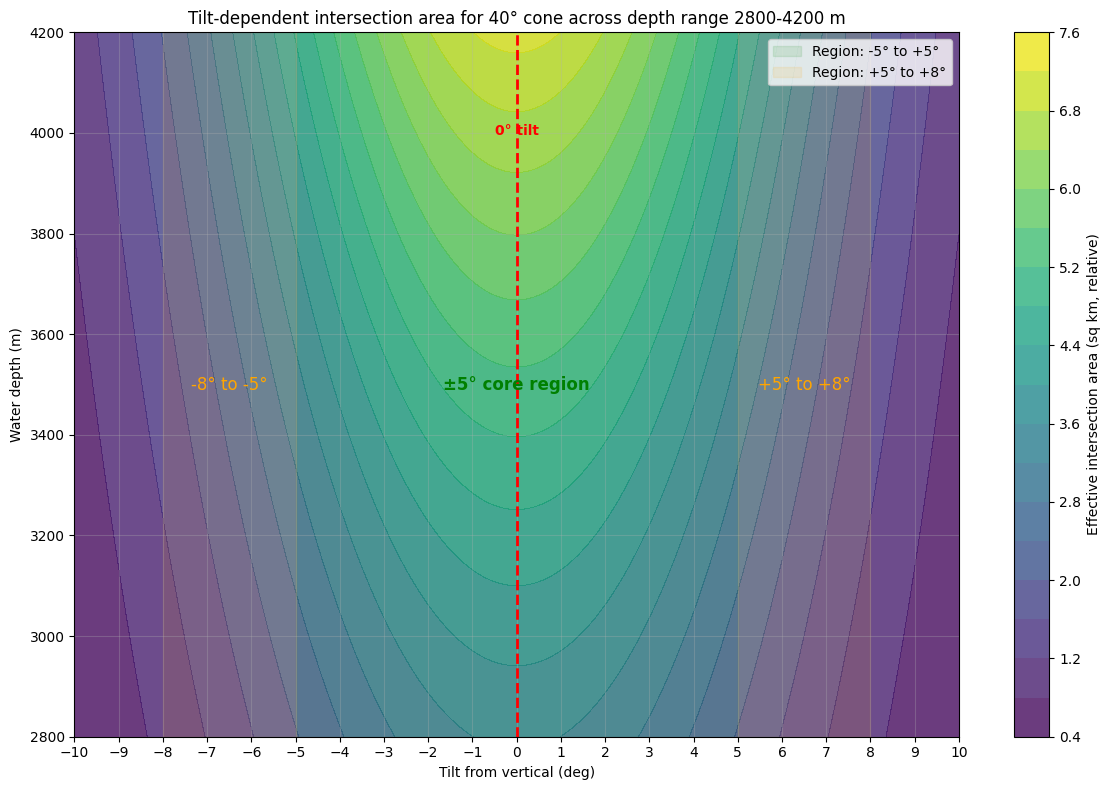

In [11]:
# Section 10: Contour Plot of Tilt vs Depth Range
# This cell creates a 2D contour plot showing how the tilt-dependent intersection area varies across the operating depth range (2800-4200m).
# The color scale represents relative area, with shaded regions highlighting tilt zones.
depth_range = np.linspace(2800, 4200, 50)  # depths from 2800 to 4200 m
tilt_range = np.linspace(-10, 10, 201)  # tilt from -10 to +10 degrees
ang = 40  # 40° cone
half = ang / 2.0
sigma = 5.0  # gaussian sigma

# Compute area grid: depth x tilt
area_grid = np.zeros((len(depth_range), len(tilt_range)))
for i, d in enumerate(depth_range):
    area_vertical = np.pi * (d * np.tan(np.radians(half)))**2 * 1e-6  # sq km at 0 tilt
    area_intersection = area_vertical * np.cos(np.radians(tilt_range))
    gaussian_weight = np.exp(-0.5 * (tilt_range / sigma) ** 2)
    area_bell = area_intersection * gaussian_weight / np.max(gaussian_weight)
    area_grid[i, :] = area_bell

# Plot contour
plt.figure(figsize=(12, 8))
cs = plt.contourf(tilt_range, depth_range, area_grid, levels=20, cmap='viridis', alpha=0.8)
plt.colorbar(cs, label='Effective intersection area (sq km, relative)')

# Highlight tilt regions with vertical bands
plt.axvspan(-5, 5, alpha=0.1, color='green', label='Region: -5° to +5°')
plt.axvspan(5, 8, alpha=0.1, color='orange', label='Region: +5° to +8°')
plt.axvspan(-8, -5, alpha=0.1, color='orange')

# Label regions
plt.text(0, depth_range.mean(), '±5° core region', color='green', ha='center', va='center', fontweight='bold', fontsize=12)
plt.text(6.5, depth_range.mean(), '+5° to +8°', color='orange', ha='center', va='center', fontsize=12)
plt.text(-6.5, depth_range.mean(), '-8° to -5°', color='orange', ha='center', va='center', fontsize=12)

# Marker for 0 tilt
plt.axvline(0, color='red', linestyle='--', linewidth=2)
plt.text(0, depth_range.max() * 0.95, '0° tilt', color='red', ha='center', va='bottom', fontweight='bold')

# X-axis ticks every degree
plt.xticks(np.arange(tilt_range.min(), tilt_range.max()+1, 1))

plt.title('Tilt-dependent intersection area for 40° cone across depth range 2800-4200 m')
plt.xlabel('Tilt from vertical (deg)')
plt.ylabel('Water depth (m)')
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

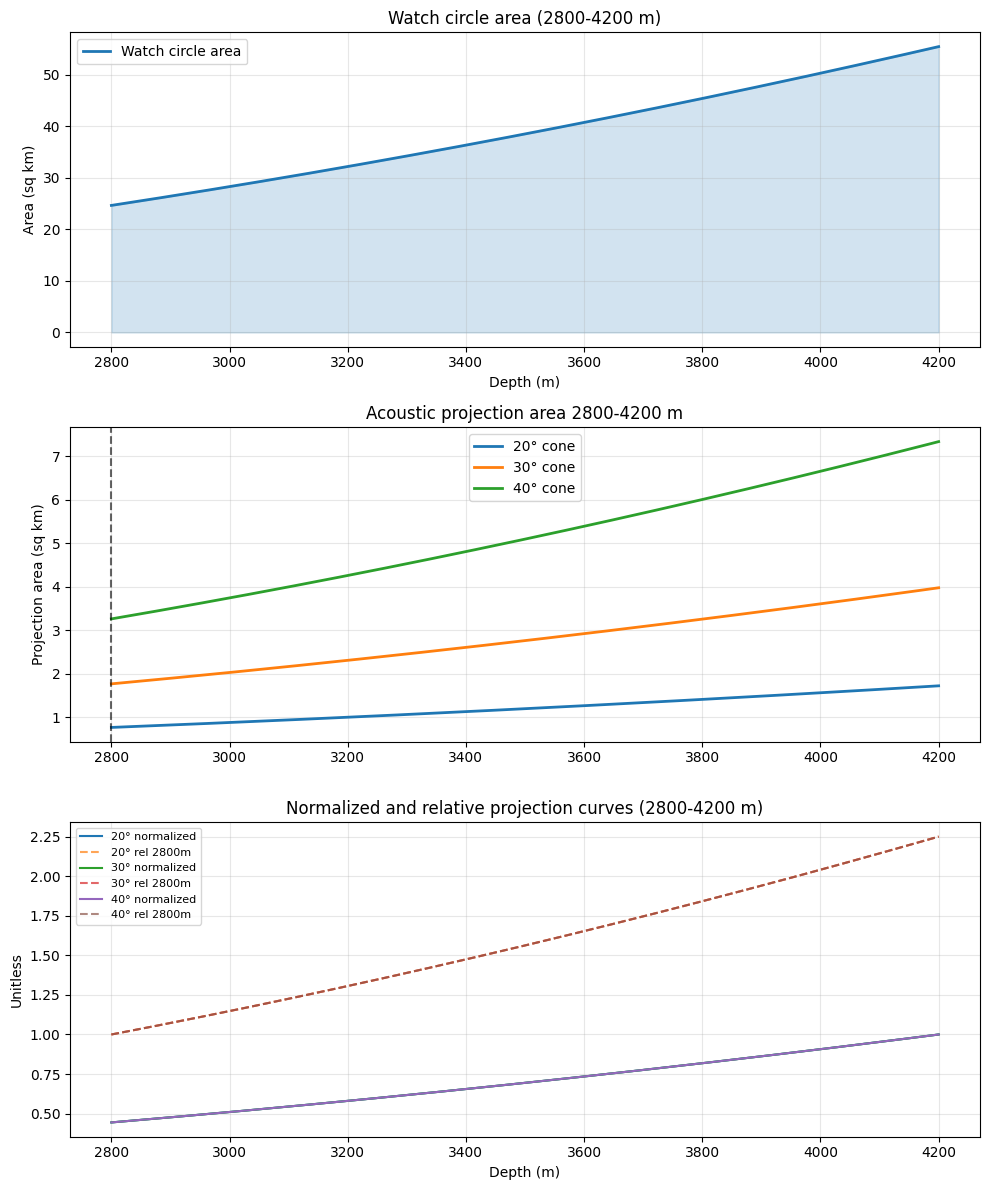

In [12]:
# depth range 2800-4200 m
depth_range = np.linspace(2800, 4200, 201)

# watch circle area on this range (same π * depth^2 scaling)
watch_circle_area_range = np.pi * depth_range**2 * 1e-6  # sq km

# acoustic projection for 20/30/40 full-cone angles (half angles 10/15/20)
projection_cones = [20, 30, 40]
area_cone_range = {
    c: np.pi * (depth_range * np.tan(np.radians(c / 2.0)))**2 * 1e-6
    for c in projection_cones
}

# normalized / relative curves on the range with anchor at 2800 m
anchor_depth = 2800
anchor_idx_range = np.argmin(np.abs(depth_range - anchor_depth))
relative_cone_range = {
    c: area_cone_range[c] / area_cone_range[c][anchor_idx_range]
    for c in projection_cones
}
normalized_cone_range = {
    c: area_cone_range[c] / area_cone_range[c].max()
    for c in projection_cones
}

# Plot
plt.figure(figsize=(10, 12))

ax1 = plt.subplot(3, 1, 1)
ax1.plot(depth_range, watch_circle_area_range, color='tab:blue', lw=2, label='Watch circle area')
ax1.fill_between(depth_range, watch_circle_area_range, alpha=0.2, color='tab:blue')
ax1.set_title('Watch circle area (2800-4200 m)')
ax1.set_xlabel('Depth (m)')
ax1.set_ylabel('Area (sq km)')
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2 = plt.subplot(3, 1, 2, sharex=ax1)
for c in projection_cones:
    ax2.plot(depth_range, area_cone_range[c], lw=2, label=f'{c}° cone')
ax2.axvline(anchor_depth, color='k', ls='--', alpha=0.6)
ax2.set_title('Acoustic projection area 2800-4200 m')
ax2.set_ylabel('Projection area (sq km)')
ax2.grid(True, alpha=0.3)
ax2.legend()

ax3 = plt.subplot(3, 1, 3, sharex=ax1)
for c in projection_cones:
    ax3.plot(depth_range, normalized_cone_range[c], label=f'{c}° normalized')
    ax3.plot(depth_range, relative_cone_range[c], ls='--', alpha=0.7, label=f'{c}° rel 2800m')
ax3.set_title('Normalized and relative projection curves (2800-4200 m)')
ax3.set_xlabel('Depth (m)')
ax3.set_ylabel('Unitless')
ax3.grid(True, alpha=0.3)
ax3.legend(fontsize=8)

plt.tight_layout()
plt.show()